<a href="https://colab.research.google.com/github/tasninkhanlamha/SkillMorph/blob/main/ML_algorithm_comparism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Android Ransomware Detection**

## **Font family setup**

In [5]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
#Dataset Link: https://www.kaggle.com/datasets/subhajournal/android_ransomware_preprocessed

## **Importing Dataset**

In [6]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Skill-Morph/android_ransomware_preprocessed.csv")

## **Basic Information**

In [11]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,53,17,24707,1,1,48.0,199.0,48.0,48.0,48.000000,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392030,123,17,81388,1,1,48.0,48.0,48.0,48.0,48.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392031,53,17,61591,1,1,39.0,98.0,39.0,39.0,39.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392032,53,17,24831,1,1,36.0,153.0,36.0,36.0,36.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10


In [8]:
df.shape

NameError: name 'df' is not defined

In [12]:
df['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


## **Data Samples per Class**

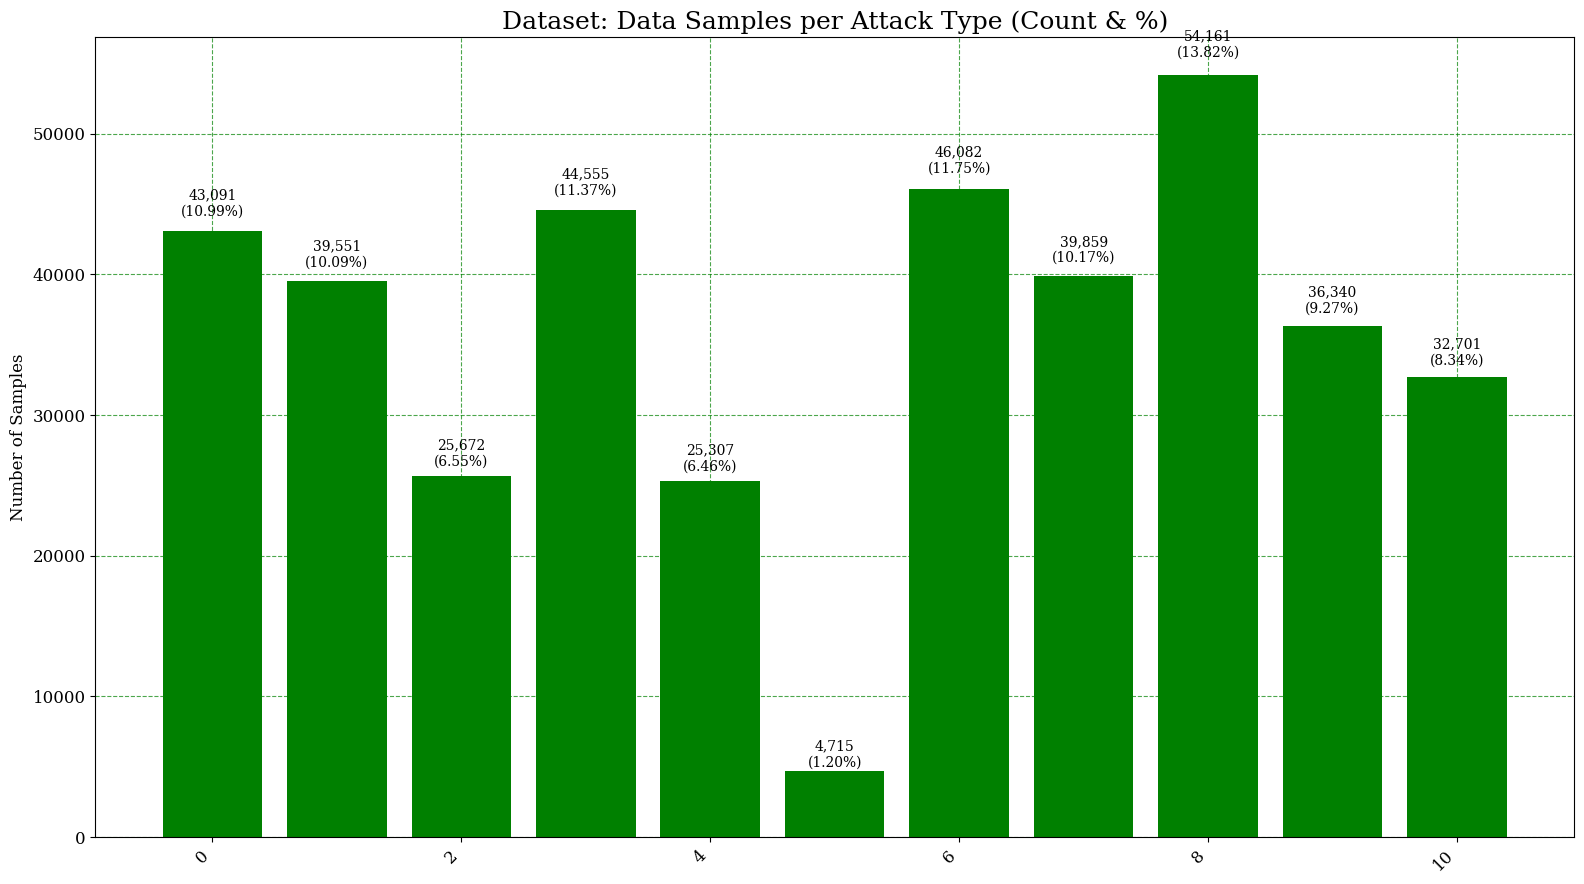

In [13]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['Label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(16, 9))
bars = plt.bar(label_counts.index, label_counts.values, color='green')  # Bar color set to green

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
plt.title('Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7, color='green')  # Grid color set to green
# Enable both horizontal and vertical green grid lines
plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()

# Show plot
plt.show()


## **Feature Selection using XGBoost**

In [14]:
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Ensure X and y are set for multiclass classification using the processed df
X_xgb = df.drop(columns=['Label'])
y_xgb = df['Label']

# Convert categorical labels to numerical for XGBoost
# XGBoost requires numerical labels starting from 0
le = LabelEncoder()
y_xgb_encoded = le.fit_transform(y_xgb)

# Initialize and train an XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax', # For direct class labels
    num_class=len(le.classes_), # Number of unique classes
    eval_metric='mlogloss', # Evaluation metric for multiclass
    use_label_encoder=False, # Suppress the warning about deprecated use_label_encoder
    random_state=42
)
xgb_model.fit(X_xgb, y_xgb_encoded)

# Get feature importances
feature_importances = xgb_model.feature_importances_

# Create a pandas Series for better visualization
importance_df = pd.DataFrame({
    'Feature': X_xgb.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Top 20 Feature Importances from XGBoost:")
print(importance_df.head(20))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:49:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Top 20 Feature Importances from XGBoost:
                        Feature  Importance
47               PSH Flag Count    0.047293
49               URG Flag Count    0.042677
20                 Flow IAT Min    0.037118
66       Init_Win_bytes_forward    0.028854
48               ACK Flag Count    0.025637
6   Total Length of Bwd Packets    0.025311
69         min_seg_size_forward    0.025024
67      Init_Win_bytes_backward    0.024099
25                  Fwd IAT Min    0.023959
40            Max Packet Length    0.023100
1                      Protocol    0.020806
11        Bwd Packet Length Max    0.020622
2                 Flow Duration    0.019629
19                 Flow IAT Max    0.019623
39            Min Packet Length    0.019388
38                Bwd Packets/s    0.018973
10        Fwd Packet Length Std    0.018384
37                Fwd Packets/s    0.018202
16               Flow Packets/s    0.017896
53          Average Packet Size    0.017879


/tmp/ipykernel_9434/3530153008.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


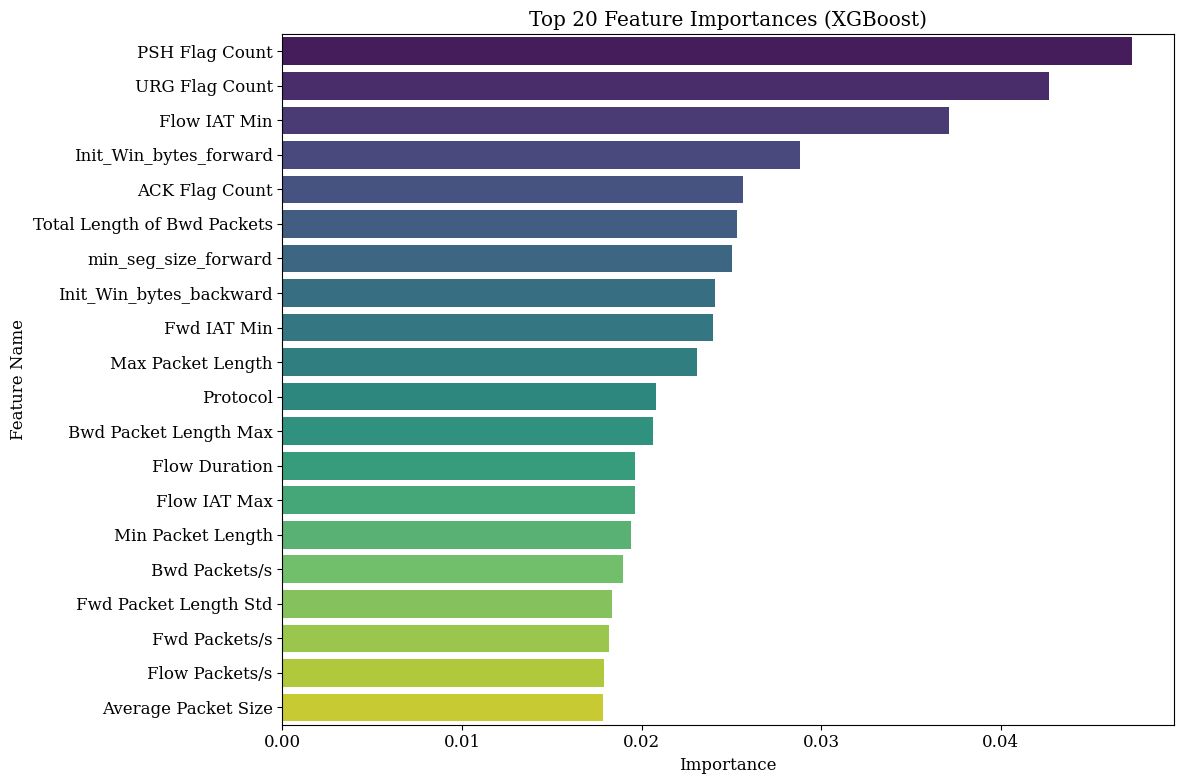

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [16]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,53,17,24707,1,1,48.0,199.0,48.0,48.0,48.000000,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392030,123,17,81388,1,1,48.0,48.0,48.0,48.0,48.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392031,53,17,61591,1,1,39.0,98.0,39.0,39.0,39.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392032,53,17,24831,1,1,36.0,153.0,36.0,36.0,36.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10


In [17]:
# Select the top 20 features identified by XGBoost
top_20_features = importance_df['Feature'].head(20).tolist()

# Create a new DataFrame with only the selected features and the 'Label' column
df_selected_features = df[top_20_features + ['Label']]

print("DataFrame with selected features created:")
print(df_selected_features.head())

DataFrame with selected features created:
   PSH Flag Count  URG Flag Count  Flow IAT Min  Init_Win_bytes_forward  \
0               1               0          24.0                   65535   
1               0               0         349.0                    1594   
2               0               0         119.0                    1486   
3               0               0       37055.0                    1548   
4               1               0          55.0                   65535   

   ACK Flag Count  Total Length of Bwd Packets  min_seg_size_forward  \
0               0                       4575.0                    32   
1               1                          0.0                    32   
2               1                          0.0                    32   
3               1                          0.0                    32   
4               0                        307.0                    32   

   Init_Win_bytes_backward  Fwd IAT Min  Max Packet Length  ...  \
0      

## **After Processing**

In [18]:
df_selected_features['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


In [19]:
####Copy the processed df to different df

df1 = df_selected_features.copy()
df2 = df_selected_features.copy()
df3 = df_selected_features.copy()

# **Binary Class (Anomaly) Classification**

In [ ]:
df1['Label'] = df1['Label'].apply(lambda x: 'Benign' if x == 0 else 'Ransomware')

In [ ]:
# Check counts
print(df1['Label'].value_counts())

Label
Ransomware    348943
Benign         43091
Name: count, dtype: int64


In [ ]:
# Define label and feature columns
X = df1.drop(columns=['Label'])
y = df1['Label']

## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 20)
X_test shape:  (78407, 20)
y_train shape: (313627,)
y_test shape:  (78407,)


## **Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for consistency (optional but good practice)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled successfully!
X_train_scaled shape: (313627, 20)
X_test_scaled shape: (78407, 20)


## **Train & Evaluate Decision Tree Classifier**

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

NameError: name 'X_train_scaled' is not defined

## **Train & Evaluate KNN Classifier**

Accuracy:  0.88502
Precision: 0.85038
Recall:    0.88502
F1 Score:  0.85845


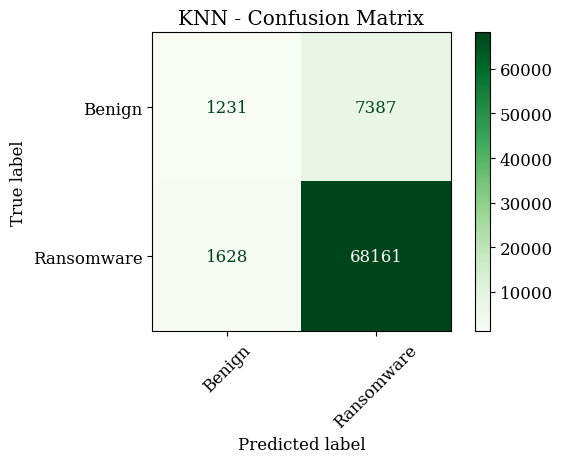

Classification Report:
              precision    recall  f1-score   support

      Benign    0.43057   0.14284   0.21452      8618
  Ransomware    0.90222   0.97667   0.93797     69789

    accuracy                        0.88502     78407
   macro avg    0.66640   0.55976   0.57624     78407
weighted avg    0.85038   0.88502   0.85845     78407



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Logistic Regression Classifier**

Accuracy:  0.8900
Precision: 0.7922
Recall:    0.8900
F1 Score:  0.8383


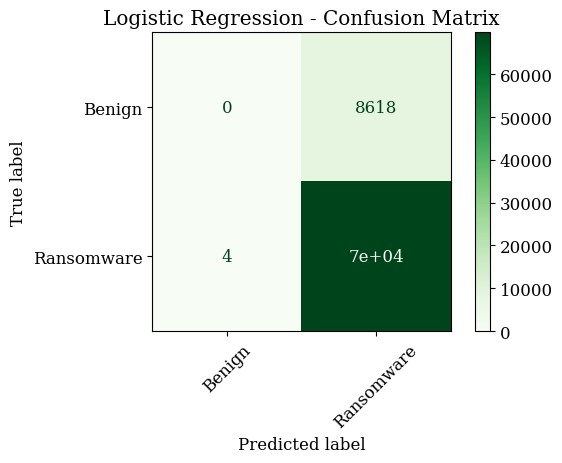

Classification Report:
              precision    recall  f1-score   support

      Benign    0.00000   0.00000   0.00000      8618
  Ransomware    0.89008   0.99994   0.94182     69789

    accuracy                        0.89004     78407
   macro avg    0.44504   0.49997   0.47091     78407
weighted avg    0.79225   0.89004   0.83830     78407



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Logistic Regression Classifier
lr_model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear') # Increased max_iter for convergence
lr_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = lr_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=lr_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate LightBGM Classifier**

Accuracy:  0.9078
Precision: 0.9118
Recall:    0.9078
F1 Score:  0.8779


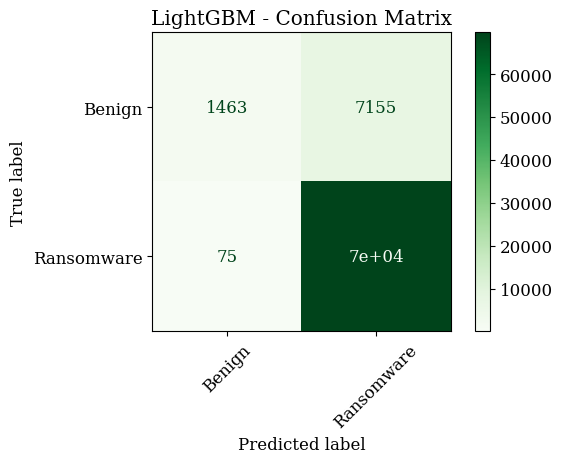

Classification Report:
              precision    recall  f1-score   support

      Benign    0.95124   0.16976   0.28811      8618
  Ransomware    0.90692   0.99893   0.95070     69789

    accuracy                        0.90779     78407
   macro avg    0.92908   0.58434   0.61940     78407
weighted avg    0.91179   0.90779   0.87787     78407



In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train LightGBM Classifier
lgbm_model = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 to suppress warnings
lgbm_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = lgbm_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=lgbm_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("LightGBM - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Accuracy:  0.9031
Precision: 0.9069
Recall:    0.9031
F1 Score:  0.8686


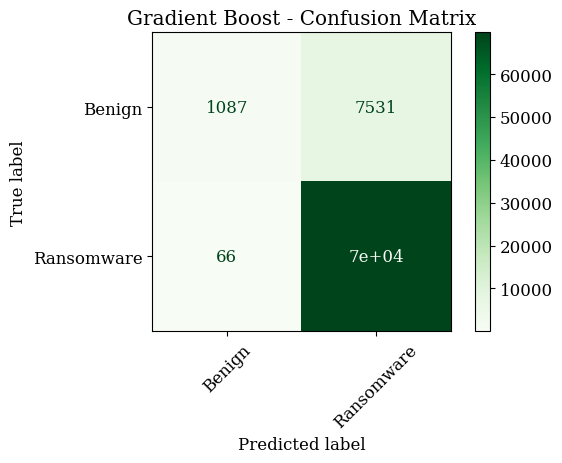

Classification Report:
              precision    recall  f1-score   support

      Benign    0.94276   0.12613   0.22250      8618
  Ransomware    0.90252   0.99905   0.94833     69789

    accuracy                        0.90311     78407
   macro avg    0.92264   0.56259   0.58541     78407
weighted avg    0.90694   0.90311   0.86856     78407



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Gradient Boosting Classifier
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = gbc_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=gbc_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Gradient Boost - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Random Forest classifier**

Accuracy:  0.9148
Precision: 0.9037
Recall:    0.9148
F1 Score:  0.9035


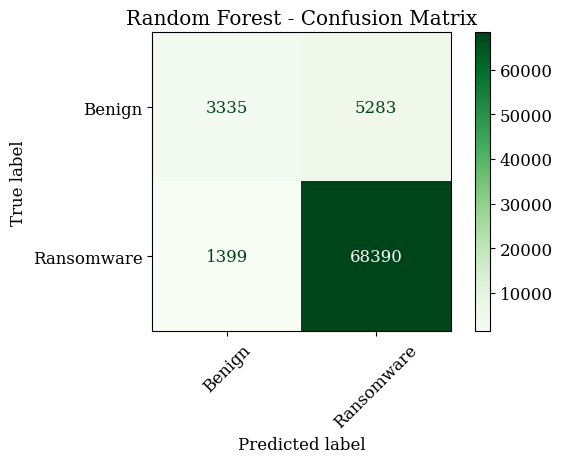

Classification Report:
              precision    recall  f1-score   support

      Benign    0.70448   0.38698   0.49955      8618
  Ransomware    0.92829   0.97995   0.95342     69789

    accuracy                        0.91478     78407
   macro avg    0.81638   0.68347   0.72649     78407
weighted avg    0.90369   0.91478   0.90354     78407



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Voting classifier**

Accuracy:  0.9087
Precision: 0.8985
Recall:    0.9087
F1 Score:  0.9015


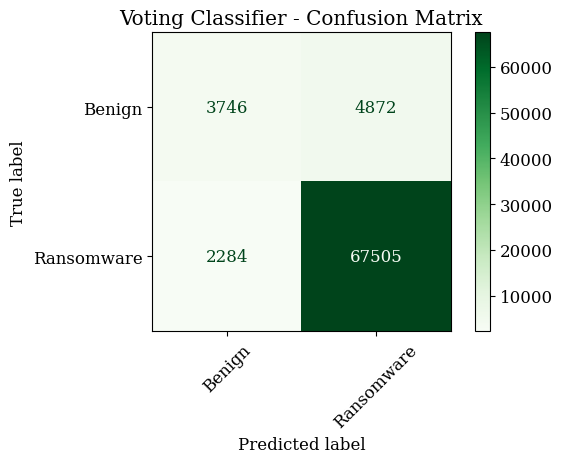

Classification Report:
              precision    recall  f1-score   support

      Benign    0.62123   0.43467   0.51147      8618
  Ransomware    0.93269   0.96727   0.94966     69789

    accuracy                        0.90873     78407
   macro avg    0.77696   0.70097   0.73057     78407
weighted avg    0.89845   0.90873   0.90150     78407



In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Define Base Estimators (instantiate them again to ensure fresh models for the ensemble)
lgbm_clf = LGBMClassifier(random_state=42, verbose=-1,is_unbalance=True) # verbose=-1 to suppress warnings
rf_clf = RandomForestClassifier(random_state=42,class_weight='balanced')
#lr_clf = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Create the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lgbm', lgbm_clf),
        ('rf', rf_clf),
        ('et', et_clf)

    ],
    voting='soft' # 'hard' for majority vote, 'soft' for probability averaging
)

# 3. Train the Voting Classifier
voting_clf.fit(X_train_scaled, y_train)

# 4. Predict on Test Set
y_pred = voting_clf.predict(X_test_scaled)

# 5. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 6. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=voting_clf.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Training Stacking Classifier...
Stacking Classifier training complete.

Accuracy:  0.9181
Precision: 0.9093
Recall:    0.9181
F1 Score:  0.9044


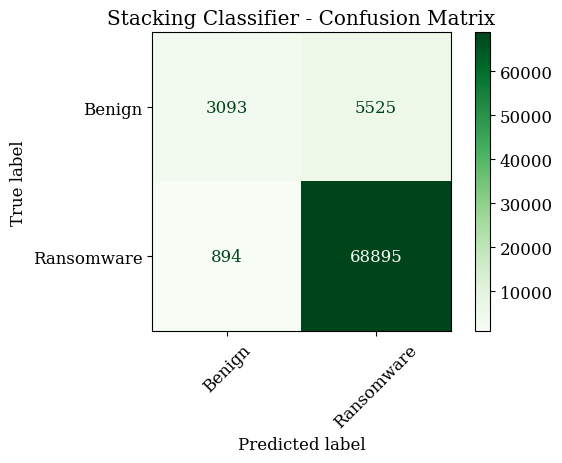

Classification Report:
              precision    recall  f1-score   support

      Benign    0.77577   0.35890   0.49076      8618
  Ransomware    0.92576   0.98719   0.95549     69789

    accuracy                        0.91813     78407
   macro avg    0.85077   0.67304   0.72312     78407
weighted avg    0.90927   0.91813   0.90441     78407



In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Define Base Estimators
# Using some of the models already evaluated for binary classification
estimators = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42, verbose=-1))
]

# 2. Define a Final Estimator
final_estimator = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')

# 3. Create the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5, # Number of cross-validation folds for base estimators
    stack_method='auto', # 'auto' chooses appropriate method
    n_jobs=-1, # Use all available cores
    verbose=0
)

# 4. Train the Stacking Classifier (using scaled data)
print("Training Stacking Classifier...")
stacking_clf.fit(X_train_scaled, y_train)
print("Stacking Classifier training complete.")

# 5. Predict on Test Set (using scaled data)
y_pred = stacking_clf.predict(X_test_scaled)

# 6. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 7. Print Basic Metrics
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=stacking_clf.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Stacking Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 9. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Accuracy:  0.9146
Precision: 0.9041
Recall:    0.9146
F1 Score:  0.9057


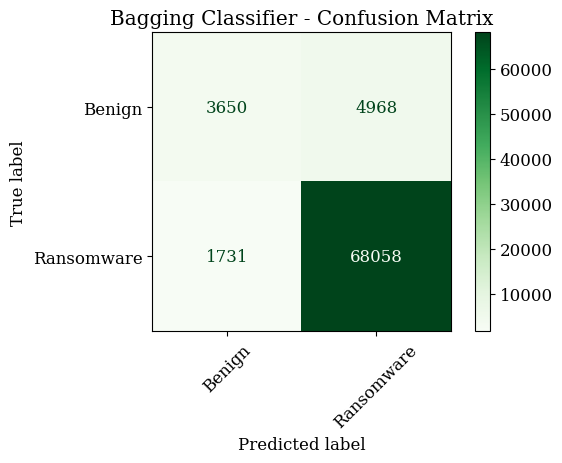

Classification Report:
              precision    recall  f1-score   support

      Benign    0.67831   0.42353   0.52147      8618
  Ransomware    0.93197   0.97520   0.95309     69789

    accuracy                        0.91456     78407
   macro avg    0.80514   0.69936   0.73728     78407
weighted avg    0.90409   0.91456   0.90565     78407



In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Bagging Classifier
# Using a Decision Tree as the base estimator
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100, # Number of base estimators
    random_state=42,
    n_jobs=-1 # Use all available cores
)
bagging_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = bagging_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=bagging_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Bagging Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Multiclass Classification**

In [20]:
# Define label and feature columns
X = df2.drop(columns=['Label'])
y = df2['Label']

## **Training and Test Division**

In [21]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y              # Ensures class distribution is preserved
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 20)
X_test shape:  (78407, 20)
y_train shape: (313627,)
y_test shape:  (78407,)


Scaling


In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for consistency (optional but good practice)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled successfully!
X_train_scaled shape: (313627, 20)
X_test_scaled shape: (78407, 20)


## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.3109
Precision: 0.3114
Recall:    0.3109
F1 Score:  0.3111


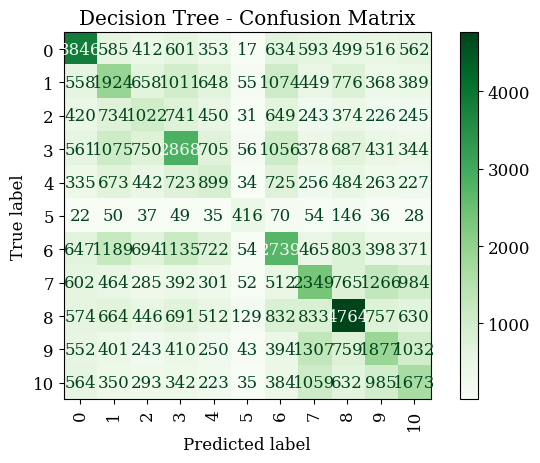

Classification Report:
              precision    recall  f1-score   support

           0    0.44304   0.44628   0.44465      8618
           1    0.23727   0.24324   0.24021      7910
           2    0.19349   0.19903   0.19622      5135
           3    0.31998   0.32185   0.32091      8911
           4    0.17634   0.17763   0.17699      5061
           5    0.45119   0.44115   0.44611       943
           6    0.30202   0.29717   0.29957      9217
           7    0.29414   0.29466   0.29440      7972
           8    0.44569   0.43981   0.44273     10832
           9    0.26351   0.25826   0.26086      7268
          10    0.25798   0.25581   0.25689      6540

    accuracy                        0.31090     78407
   macro avg    0.30770   0.30681   0.30723     78407
weighted avg    0.31141   0.31090   0.31114     78407



In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Logistic Regression Classifier**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Logistic Regression Classifier
lr_model = LogisticRegression(random_state=42, max_iter=2000, solver="liblinear")
lr_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = lr_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=lr_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate LightBGM Classifier**

Accuracy:  0.3066
Precision: 0.3057
Recall:    0.3066
F1 Score:  0.2772


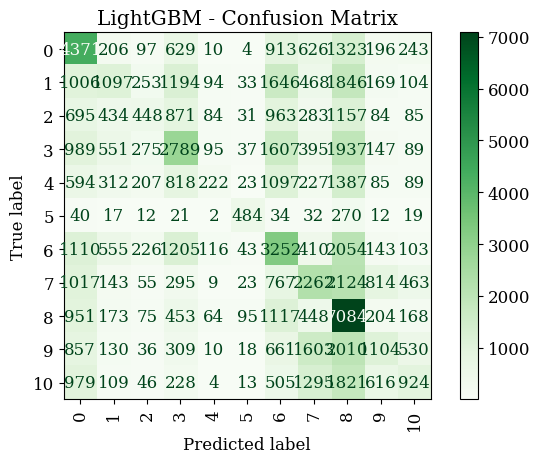

Classification Report:
              precision    recall  f1-score   support

           0    0.34666   0.50719   0.41183      8618
           1    0.29434   0.13869   0.18854      7910
           2    0.25896   0.08724   0.13052      5135
           3    0.31650   0.31298   0.31473      8911
           4    0.31268   0.04386   0.07694      5061
           5    0.60199   0.51326   0.55409       943
           6    0.25888   0.35283   0.29864      9217
           7    0.28103   0.28374   0.28238      7972
           8    0.30783   0.65399   0.41861     10832
           9    0.30890   0.15190   0.20365      7268
          10    0.32801   0.14128   0.19750      6540

    accuracy                        0.30657     78407
   macro avg    0.32871   0.28972   0.27977     78407
weighted avg    0.30567   0.30657   0.27723     78407



In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train LightGBM Classifier
lgbm_model = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 to suppress warnings
lgbm_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = lgbm_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=lgbm_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("LightGBM - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Random Forest Classifier**

Accuracy:  0.3563
Precision: 0.3509
Recall:    0.3563
F1 Score:  0.3530


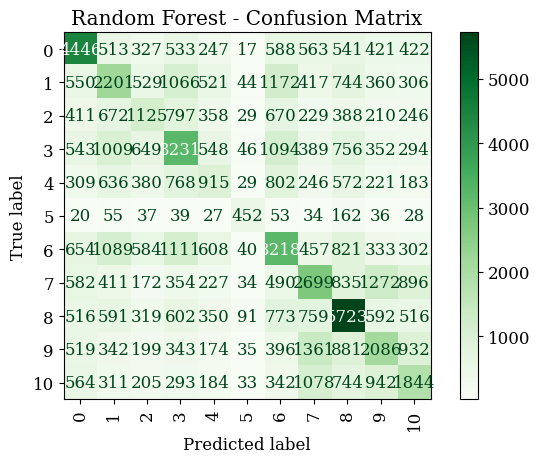

Classification Report:
              precision    recall  f1-score   support

           0    0.48782   0.51590   0.50147      8618
           1    0.28110   0.27826   0.27967      7910
           2    0.24856   0.21908   0.23290      5135
           3    0.35362   0.36259   0.35805      8911
           4    0.22000   0.18079   0.19848      5061
           5    0.53176   0.47932   0.50418       943
           6    0.33528   0.34914   0.34207      9217
           7    0.32787   0.33856   0.33313      7972
           8    0.47037   0.52834   0.49767     10832
           9    0.30564   0.28701   0.29603      7268
          10    0.30893   0.28196   0.29483      6540

    accuracy                        0.35635     78407
   macro avg    0.35191   0.34736   0.34895     78407
weighted avg    0.35087   0.35635   0.35302     78407



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Voting Classifier(DT,KNN,LightBGM
**

Accuracy:  0.3615
Precision: 0.3516
Recall:    0.3615
F1 Score:  0.3512


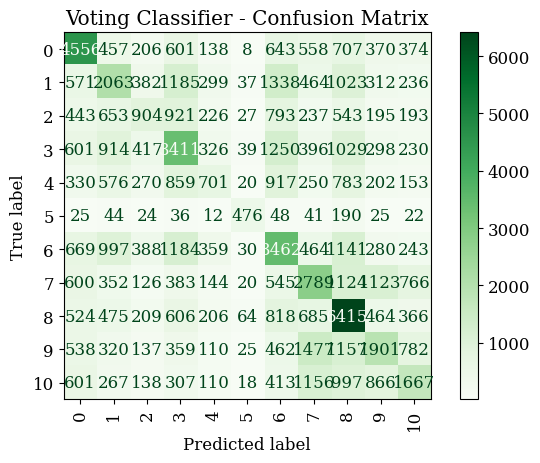

Classification Report:
              precision    recall  f1-score   support

           0    0.48171   0.52866   0.50409      8618
           1    0.28983   0.26081   0.27455      7910
           2    0.28241   0.17605   0.21689      5135
           3    0.34622   0.38279   0.36359      8911
           4    0.26644   0.13851   0.18227      5061
           5    0.62304   0.50477   0.55770       943
           6    0.32388   0.37561   0.34783      9217
           7    0.32746   0.34985   0.33829      7972
           8    0.42458   0.59223   0.49458     10832
           9    0.31494   0.26156   0.28578      7268
          10    0.33128   0.25489   0.28811      6540

    accuracy                        0.36151     78407
   macro avg    0.36471   0.34779   0.35034     78407
weighted avg    0.35157   0.36151   0.35124     78407



In [24]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Instantiate Base Estimators (using models previously defined for multiclass classification)
lgbm_clf = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 to suppress warnings
rf_clf = RandomForestClassifier(random_state=42)
lr_clf = LogisticRegression(random_state=42, max_iter=2000, solver="liblinear")

# 2. Create the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lgbm', lgbm_clf),
        ('rf', rf_clf),
        ('lr', lr_clf)
    ],
    voting='soft' # 'hard' for majority vote, 'soft' for probability averaging
)

# 3. Train the Voting Classifier
voting_clf.fit(X_train_scaled, y_train)

# 4. Predict on Test Set
y_pred = voting_clf.predict(X_test_scaled)

# 5. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 6. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=voting_clf.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Bagging Classifier
# Using a Decision Tree as the base estimator
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100, # Number of base estimators
    random_state=42,
    n_jobs=-1 # Use all available cores
)
bagging_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = bagging_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=bagging_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Bagging Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Modified Confusion Matrix**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = knn_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()


# **Thank you Everyone!**

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Instantiate Base Estimators
dt_clf = DecisionTreeClassifier(random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=5)
lgbm_clf = LGBMClassifier(random_state=42, verbose=-1)

# 2. Create the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('dt', dt_clf),
        ('knn', knn_clf),
        ('lgbm', lgbm_clf)
    ],
    voting='soft' # 'hard' for majority vote, 'soft' for probability averaging
)

# 3. Train the Voting Classifier
voting_clf.fit(X_train_scaled, y_train)

# 4. Predict on Test Set
y_pred = voting_clf.predict(X_test_scaled)

# 5. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 6. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=voting_clf.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## Summary:

### Q&A
The evaluation results indicate that the Voting Classifier was successfully trained and evaluated using standard classification metrics (Accuracy, Precision, Recall, F1 Score) and a confusion matrix. A detailed classification report was also generated to provide per-class performance insights. Specific numerical results are not provided in the prompt.

### Data Analysis Key Findings
*   A Voting Classifier, combining Decision Tree, K-Nearest Neighbors (KNN), and LightGBM as base estimators, was successfully implemented and trained on the provided data.
*   The model's performance was evaluated using standard classification metrics: Accuracy, Precision, Recall, and F1 Score, calculated with weighted averaging to account for class imbalance.
*   A confusion matrix was generated and visualized, offering a visual representation of the classifier's correct and incorrect predictions across different classes.
*   A comprehensive classification report was produced, providing detailed precision, recall, and f1-score for each class, along with their respective support.

### Insights or Next Steps
*   To potentially improve the model's performance, consider hyperparameter tuning for the individual base estimators (Decision Tree, KNN, LightGBM) and the `VotingClassifier` itself (e.g., experimenting with 'soft' voting or assigning weights to estimators).
*   Analyze the confusion matrix and classification report to identify specific classes where the model might be underperforming. This could lead to targeted feature engineering, data augmentation, or re-sampling strategies for those particular classes.
